In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

In [2]:
# --- Load the cleaned and transformed dataset ---
df = pd.read_csv("merged_data.csv")
df.head()

,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,rest_index,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,98.253896,Amsterdam,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,837.280757,Amsterdam,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,95.386955,Amsterdam,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,875.033098,Amsterdam,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,815.305740,Amsterdam,1


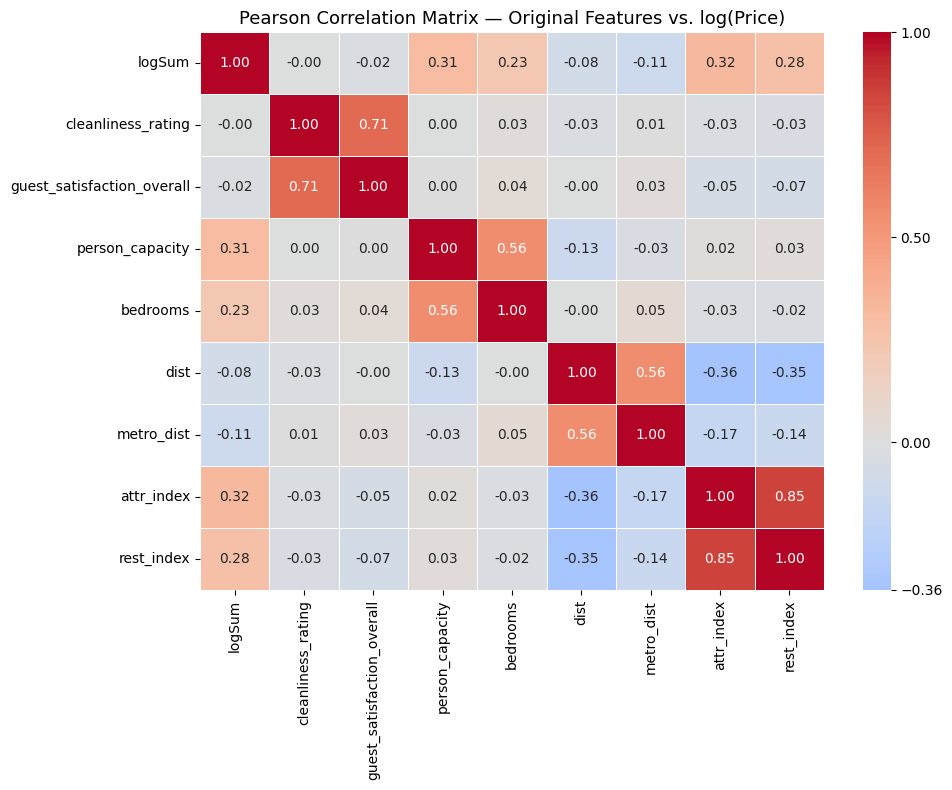

In [3]:
# --- Correlation Matrix: Original Features ---

numeric_cols = [
    "logSum",
    "cleanliness_rating",
    "guest_satisfaction_overall",
    "person_capacity", 
    "bedrooms", 
    "dist", 
    "metro_dist",
    "attr_index", 
    "rest_index"]

corr_matrix_orig = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix_orig,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"ticks": [1.0, 0.5, 0.0, -0.36]},
)
ax.set_title("Pearson Correlation Matrix — Original Features vs. log(Price)", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix_original.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
# --- Full-feature PCA ---
# All continuous numeric predictors; excludes targets (realSum, logSum),
# binary/categorical cols, and the satisfaction PCs already derived above.
# All components computed; projection onto top 2 is used in the scatter below.

all_numeric_cols = [
    "person_capacity",
    "cleanliness_rating", "guest_satisfaction_overall",
    "bedrooms", "dist", "metro_dist",
    "attr_index", "rest_index",
]

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(df[all_numeric_cols])

pca_full = PCA(n_components=len(all_numeric_cols), random_state=42)
pc_full = pca_full.fit_transform(X_full_scaled)

print("Explained variance ratio per component:")
cumulative = 0.0
for i, evr in enumerate(pca_full.explained_variance_ratio_, 1):
    cumulative += evr
    print(f"  PC{i:02d}: {evr:.3f}  (cumulative: {cumulative:.3f})")

print("\nLoadings (rows = features, cols = PCs):")
loading_df = pd.DataFrame(
    pca_full.components_.T,
    index=all_numeric_cols,
    columns=[f"PC{i}" for i in range(1, len(all_numeric_cols) + 1)],
)
print(loading_df.round(3).to_string())


Explained variance ratio per component:
  PC01: 0.283  (cumulative: 0.283)
  PC02: 0.215  (cumulative: 0.498)
  PC03: 0.193  (cumulative: 0.692)
  PC04: 0.150  (cumulative: 0.841)
  PC05: 0.056  (cumulative: 0.897)
  PC06: 0.049  (cumulative: 0.946)
  PC07: 0.036  (cumulative: 0.982)
  PC08: 0.018  (cumulative: 1.000)

Loadings (rows = features, cols = PCs):
                              PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
person_capacity             0.077  0.192  0.676  0.009 -0.614  0.349  0.013  0.015
cleanliness_rating         -0.080  0.670 -0.207  0.053 -0.020  0.039 -0.705  0.024
guest_satisfaction_overall -0.108  0.667 -0.195  0.053  0.009  0.023  0.707 -0.034
bedrooms                   -0.006  0.210  0.670  0.109  0.651 -0.267 -0.022 -0.006
dist                       -0.473 -0.139 -0.022  0.444  0.274  0.695 -0.007 -0.001
metro_dist                 -0.349 -0.073  0.023  0.674 -0.342 -0.548 -0.005  0.027
attr_index                  0.564  0.024 -0.084  0.394  0.

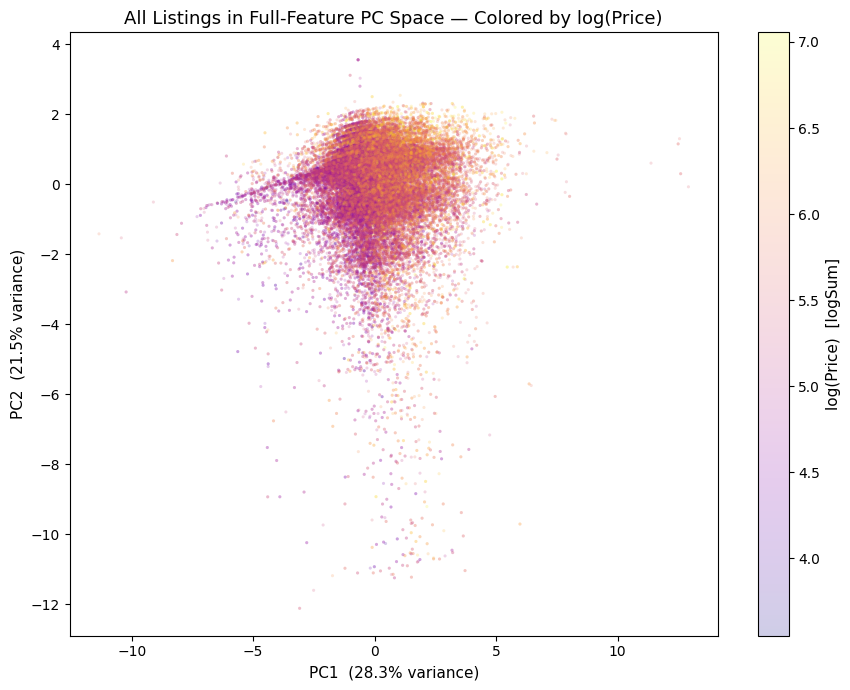

In [5]:
# --- Scatter: all listings in full-feature PC space, colored by log(Price) ---
fig, ax = plt.subplots(figsize=(9, 7))

sc_full = ax.scatter(
    pc_full[:, 0],
    pc_full[:, 1],
    c=df["logSum"],
    cmap="plasma",
    alpha=0.2,
    s=5,
    linewidths=0,
)

cbar = fig.colorbar(sc_full, ax=ax)
cbar.set_label("log(Price)  [logSum]", fontsize=11)

ax.set_xlabel(f"PC1  ({pca_full.explained_variance_ratio_[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({pca_full.explained_variance_ratio_[1]:.1%} variance)", fontsize=11)
ax.set_title("All Listings in Full-Feature PC Space — Colored by log(Price)", fontsize=13)

plt.tight_layout()
plt.savefig("pca_full_scatter_logprice.png", dpi=300, bbox_inches="tight")
plt.show()
